# **Eksplorasi Data**

## **1. Statistik Deskriptif Dasar**

### **1.1 Jumlah Setiap Kelas**
![Distribusi Species Iris](../images/species_distribusi.png)

**Hasil**:
- Iris-setosa: 50 sampel (33.33%)
- Iris-versicolor: 50 sampel (33.33%)
- Iris-virginica: 50 sampel (33.33%)

**Insight**: Dataset perfectly balanced - tidak ada bias kelas, ideal untuk machine learning.

### **1.2 Min-Max Setiap Kolom**
![Min_Max_kolom](../images/min_max_kolom.png)

**Hasil Analisis**:
- **sepal_length**: 4.3 - 7.9 cm (range: 3.6 cm)
- **sepal_width**: 2.0 - 4.4 cm (range: 2.4 cm)
- **petal_length**: 1.0 - 6.9 cm (range: 5.9 cm)
- **petal_width**: 0.1 - 2.5 cm (range: 2.4 cm)

**Insight**: Petal length memiliki variasi terbesar (5.9 cm), menunjukkan karakteristik yang paling beragam antar spesies.

### **1.3 Outlayer**
![Min_Max_kolom](../images/outlayer.png)

**1. Petal Length vs Petal Width**
- Grafik kiri menunjukkan hubungan antara **petal_length** dan **petal_width**.
- Setiap spesies iris (setosa, versicolor, virginica) terpisah jelas, terutama **iris-setosa** di kiri bawah.
- Fitur petal sangat baik untuk membedakan spesies karena sebaran datanya tidak saling tumpang tindih.

**2. Sepal Length vs Sepal Width**
- Grafik kanan menunjukkan hubungan antara **sepal_length** dan **sepal_width**.
- Distribusi antar spesies lebih tumpang tindih, sehingga lebih sulit membedakan satu sama lain.
- Fitur sepal kurang efektif untuk klasifikasi dibandingkan petal.

**Kesimpulan:**  
Petal length dan petal width merupakan fitur terbaik untuk klasifikasi spesies iris, sedangkan sepal length dan sepal width kurang optimal.

### **1.4 Tabel Ringkasan Statistik Lengkap**

| Statistik | sepal_length | sepal_width | petal_length | petal_width |
|-----------|--------------|-------------|--------------|-------------|
| **Mean/Rata-Rata** | 5.84 | 3.05 | 3.76 | 1.20 |
| **Median** | 5.80 | 3.00 | 4.35 | 1.30 |
| **Std Dev** | 0.83 | 0.43 | 1.76 | 0.76 |
| **Variance** | 0.69 | 0.19 | 3.09 | 0.58 |
| **Min** | 4.30 | 2.00 | 1.00 | 0.10 |
| **Max** | 7.90 | 4.40 | 6.90 | 2.50 |
| **Range** | 3.60 | 2.40 | 5.90 | 2.40 |

#### **1.4.1 Rata-rata Setiap Kolom**

**Hasil Analisis**:
- **sepal_length**: ~5.84 cm 
- **sepal_width**: ~3.05 cm 
- **petal_length**: ~3.76 cm 
- **petal_width**: ~1.20 cm 

**Insight**: Sepal umumnya lebih besar dari petal, dengan width selalu lebih kecil dari length.

#### **1.4.2 Median Setiap Kolom**

**Hasil Analisis**:
- **sepal_length**: ~5.80 cm (mendekati mean, distribusi simetris)
- **sepal_width**: ~3.00 cm (mendekati mean, distribusi normal)
- **petal_length**: ~4.35 cm (lebih besar dari mean, skew ke kiri)
- **petal_width**: ~1.30 cm (lebih besar dari mean, skew ke kiri)

**Insight**: Petal measurements cenderung skewed karena perbedaan besar antara Iris-setosa dengan spesies lainnya.

#### **1.4.3 Standard Deviasi Setiap Kolom**

**Hasil Analisis**:
- **sepal_length**: ~0.83 cm (variabilitas sedang)
- **sepal_width**: ~0.43 cm (variabilitas rendah)
- **petal_length**: ~1.76 cm (variabilitas tinggi)
- **petal_width**: ~0.76 cm (variabilitas sedang-tinggi)

**Insight**: Petal length memiliki variabilitas tertinggi, mengkonfirmasi bahwa ini adalah feature yang paling diskriminatif.

#### **1.4.4 Variance Setiap Kolom**

**Hasil Analisis**:
- **sepal_length**: ~0.69 cm² (variance sedang)
- **sepal_width**: ~0.19 cm² (variance rendah)
- **petal_length**: ~3.10 cm² (variance tertinggi)
- **petal_width**: ~0.58 cm² (variance sedang)

**Insight**: Variance menguatkan temuan bahwa petal length memiliki dispersi data terbesar antar spesies.


## **2. Outlier Detection**

In [1]:
import pandas as pd
from pycaret.anomaly import * 
import matplotlib.pyplot as plt

### **2.1 ABOD (Angle-base Outlier Detection)**

#### **2.1.1 Menyiapkan model (ABOD)**

In [2]:
data = pd.read_csv("../IRIS.csv")
data = data.drop(columns=["species"])

s = setup(data)

abod = create_model('abod', fraction=0.05) 
results = assign_model(abod)

results_sorted = results.sort_values(by="Anomaly", ascending=False)

,Description,Value
0,Session id,839
1,Original data shape,"(150, 4)"
2,Transformed data shape,"(150, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


#### **2.1.2 Ringkasan hasil outlier detection (tampilkan 10 baris pertama)**

In [3]:
print("Ringkasan Hasil Outlier Detection (10 baris pertama):")
results_sorted[['sepal_length','sepal_width','petal_length','petal_width','Anomaly','Anomaly_Score']].head(10)


Ringkasan Hasil Outlier Detection (10 baris pertama):


,sepal_length,sepal_width,petal_length,petal_width,Anomaly,Anomaly_Score
131,7.9,3.8,6.4,2.0,1,-0.137417
62,6.0,2.2,4.0,1.0,1,-0.289391
108,6.7,2.5,5.8,1.8,1,-0.084224
106,4.9,2.5,4.5,1.7,1,-0.050388
117,7.7,3.8,6.7,2.2,1,-0.129286
100,6.3,3.3,6.0,2.5,1,-0.364475
134,6.1,2.6,5.6,1.4,1,-0.309969
41,4.5,2.3,1.3,0.3,1,-0.088998
84,5.4,3.0,4.5,1.5,0,-3.127326
97,6.2,2.9,4.3,1.3,0,-29.977802


#### **2.1.3 Hitung jumlah outlier dan normal**

In [4]:
outlier_count = results['Anomaly'].sum()
normal_count = len(results) - outlier_count
total_count = len(results)
outlier_percent = (outlier_count / total_count) * 100

print("\n Statistik Outlier:")
print(f"Total Data     : {total_count}")
print(f"Normal Data    : {normal_count}")
print(f"Outlier Data   : {outlier_count}")
print(f"Persentase Outlier : {outlier_percent:.2f}%")

summary_df = pd.DataFrame({
    'Kategori': ['Normal', 'Outlier'],
    'Jumlah': [normal_count, outlier_count],
    'Persentase': [100 - outlier_percent, outlier_percent]
})
print("\n Ringkasan Jumlah Data:")
print(summary_df)


 Statistik Outlier:
Total Data     : 150
Normal Data    : 142
Outlier Data   : 8
Persentase Outlier : 5.33%

 Ringkasan Jumlah Data:
  Kategori  Jumlah  Persentase
0   Normal     142   94.666667
1  Outlier       8    5.333333


#### **2.1.4 Visualisasi Outlier**

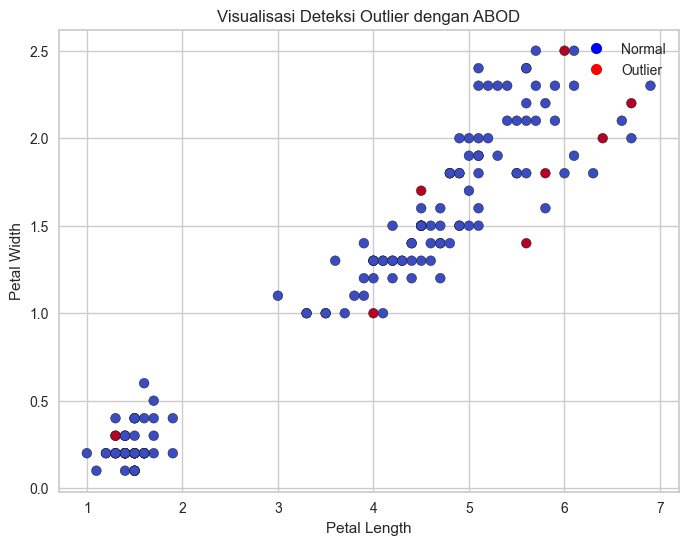

In [5]:
# Buat scatter plot dengan dua fitur utama
plt.figure(figsize=(8,6))
plt.scatter(
    results['petal_length'], results['petal_width'],
    c=results['Anomaly'], cmap='coolwarm', edgecolor='k'
)

# Tambahkan judul dan label
plt.title("Visualisasi Deteksi Outlier dengan ABOD")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

# Tambahkan legenda
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Normal',
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Outlier',
               markerfacecolor='red', markersize=8)
]
plt.legend(handles=handles)

### **2.2 KNN (k-Nearest Neighbors Detector)**

#### **2.2.1 Menyiapkan model (KNN)**

In [6]:
data = pd.read_csv("../IRIS.csv")
data = data.drop(columns=["species"])

s = setup(data)

knn = create_model('knn', fraction=0.05) 
results = assign_model(knn)

results_sorted = results.sort_values(by="Anomaly", ascending=False)

,Description,Value
0,Session id,5509
1,Original data shape,"(150, 4)"
2,Transformed data shape,"(150, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


#### **2.2.2 Ringkasan hasil outlier detection (tampilkan 10 baris pertama)**

In [7]:
# Ringkasan hasil outlier detection (tampilkan 10 baris pertama)
print("Ringkasan Hasil Outlier Detection (10 baris pertama):")
results_sorted[['sepal_length','sepal_width','petal_length','petal_width','Anomaly','Anomaly_Score']].head(10)

Ringkasan Hasil Outlier Detection (10 baris pertama):


,sepal_length,sepal_width,petal_length,petal_width,Anomaly,Anomaly_Score
131,7.9,3.8,6.4,2.0,1,1.024695
57,4.9,2.4,3.3,1.0,1,0.787401
109,7.2,3.6,6.1,2.5,1,0.806226
106,4.9,2.5,4.5,1.7,1,0.883176
117,7.7,3.8,6.7,2.2,1,1.019804
118,7.7,2.6,6.9,2.3,1,0.964365
98,5.1,2.5,3.0,1.1,1,0.818535
41,4.5,2.3,1.3,0.3,1,0.793726
84,5.4,3.0,4.5,1.5,0,0.509902
82,5.8,2.7,3.9,1.2,0,0.346410


#### **2.2.3 Hitung jumlah outlier dan normal**

In [8]:
outlier_count = results['Anomaly'].sum()
normal_count = len(results) - outlier_count
total_count = len(results)
outlier_percent = (outlier_count / total_count) * 100

print("\n Statistik Outlier:")
print(f"Total Data     : {total_count}")
print(f"Normal Data    : {normal_count}")
print(f"Outlier Data   : {outlier_count}")
print(f"Persentase Outlier : {outlier_percent:.2f}%")

summary_df = pd.DataFrame({
    'Kategori': ['Normal', 'Outlier'],
    'Jumlah': [normal_count, outlier_count],
    'Persentase': [100 - outlier_percent, outlier_percent]
})
print("\n Ringkasan Jumlah Data:")
print(summary_df)


 Statistik Outlier:
Total Data     : 150
Normal Data    : 142
Outlier Data   : 8
Persentase Outlier : 5.33%

 Ringkasan Jumlah Data:
  Kategori  Jumlah  Persentase
0   Normal     142   94.666667
1  Outlier       8    5.333333


#### **2.2.4 Visualisasi Outlier**

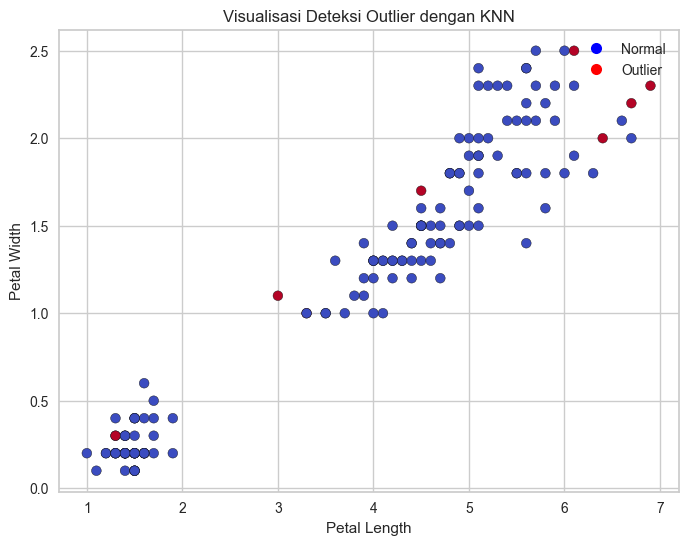

In [9]:
# Buat scatter plot dengan dua fitur utama
plt.figure(figsize=(8,6))
plt.scatter(
    results['petal_length'], results['petal_width'],
    c=results['Anomaly'], cmap='coolwarm', edgecolor='k'
)

# Tambahkan judul dan label
plt.title("Visualisasi Deteksi Outlier dengan KNN")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

# Tambahkan legenda
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Normal',
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Outlier',
               markerfacecolor='red', markersize=8)
]
plt.legend(handles=handles)

plt.show()

### **2.3 LOF (Local Outlier Factor)**

#### **2.3.1 Menyiapkan model (LOF)**

In [10]:
data = pd.read_csv("../IRIS.csv")
data = data.drop(columns=["species"])

s = setup(data)

lof = create_model('lof', fraction=0.05) 
results = assign_model(lof)

results_sorted = results.sort_values(by="Anomaly", ascending=False)

,Description,Value
0,Session id,1964
1,Original data shape,"(150, 4)"
2,Transformed data shape,"(150, 4)"
3,Numeric features,4
4,Preprocess,True
5,Imputation type,simple
6,Numeric imputation,mean
7,Categorical imputation,mode
8,CPU Jobs,-1
9,Use GPU,False


#### **2.3.2 Ringkasan hasil outlier detection (tampilkan 10 baris pertama)**

In [11]:
# Ringkasan hasil outlier detection (tampilkan 10 baris pertama)
print("Ringkasan Hasil Outlier Detection (10 baris pertama):")
results_sorted[['sepal_length','sepal_width','petal_length','petal_width','Anomaly','Anomaly_Score']].head(10)

Ringkasan Hasil Outlier Detection (10 baris pertama):


,sepal_length,sepal_width,petal_length,petal_width,Anomaly,Anomaly_Score
122,7.7,2.8,6.7,2.0,1,1.491365
118,7.7,2.6,6.9,2.3,1,1.624653
41,4.5,2.3,1.3,0.3,1,1.777233
98,5.1,2.5,3.0,1.1,1,1.511868
15,5.7,4.4,1.5,0.4,1,1.653626
14,5.8,4.0,1.2,0.2,1,1.463125
131,7.9,3.8,6.4,2.0,1,1.547288
117,7.7,3.8,6.7,2.2,1,1.572990
106,4.9,2.5,4.5,1.7,0,1.374999
105,7.6,3.0,6.6,2.1,0,1.399554


#### **2.3.3 Hitung jumlah outlier dan normal**

In [12]:
outlier_count = results['Anomaly'].sum()
normal_count = len(results) - outlier_count
total_count = len(results)
outlier_percent = (outlier_count / total_count) * 100

print("\n Statistik Outlier:")
print(f"Total Data     : {total_count}")
print(f"Normal Data    : {normal_count}")
print(f"Outlier Data   : {outlier_count}")
print(f"Persentase Outlier : {outlier_percent:.2f}%")

# Visualisasi tabel ringkas (opsional, misalnya untuk notebook)
summary_df = pd.DataFrame({
    'Kategori': ['Normal', 'Outlier'],
    'Jumlah': [normal_count, outlier_count],
    'Persentase': [100 - outlier_percent, outlier_percent]
})
print("\n Ringkasan Jumlah Data:")
print(summary_df)


 Statistik Outlier:
Total Data     : 150
Normal Data    : 142
Outlier Data   : 8
Persentase Outlier : 5.33%

 Ringkasan Jumlah Data:
  Kategori  Jumlah  Persentase
0   Normal     142   94.666667
1  Outlier       8    5.333333


#### **2.3.4 Visualisasi Outlier**

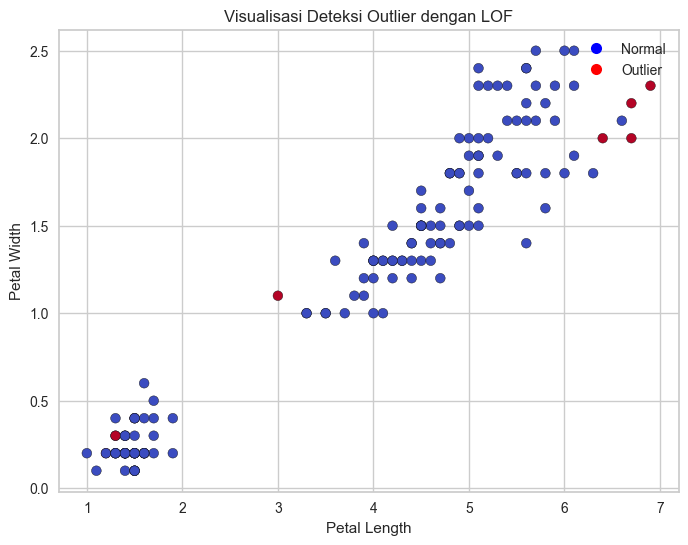

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(
    results['petal_length'], results['petal_width'],
    c=results['Anomaly'], cmap='coolwarm', edgecolor='k'
)

# Tambahkan judul dan label
plt.title("Visualisasi Deteksi Outlier dengan LOF")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

# Tambahkan legenda
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label='Normal',
               markerfacecolor='blue', markersize=8),
    plt.Line2D([0], [0], marker='o', color='w', label='Outlier',
               markerfacecolor='red', markersize=8)
]
plt.legend(handles=handles)

plt.show()